In [6]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn joblib
!pip install pandas
import pandas as pd

data = pd.read_csv("behavior_pipeline/data/final_gaming_behavioral_dataset_20_features.csv")

print(data.head())
print(data.shape)

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 390.8 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 650.1 kB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.wh


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   daily_play_time_hours  weekly_play_time_hours  sessions_per_day  \
0               5.556292               11.927813                 9   
1              13.334643                9.556530                 4   
2              10.381918               50.314396                 6   
3               8.581890               77.458724                 8   
4               2.606252               42.704098                10   

   avg_session_duration_min  late_night_play_ratio  days_played_per_week  \
0                118.886623               0.557380                     4   
1                 65.990109               0.252907                     6   
2                  6.409151               0.476240                     2   
3                 10.093718               0.116955                     2   
4                 57.758115               0.000000                     3   

   longest_play_streak_days  binge_sessions_

In [7]:
from sklearn.model_selection import train_test_split

X = data.drop("addiction_label", axis=1)
y = data["addiction_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

c:\Users\khush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9722
Decision Tree: 0.9994
Random Forest: 0.9986


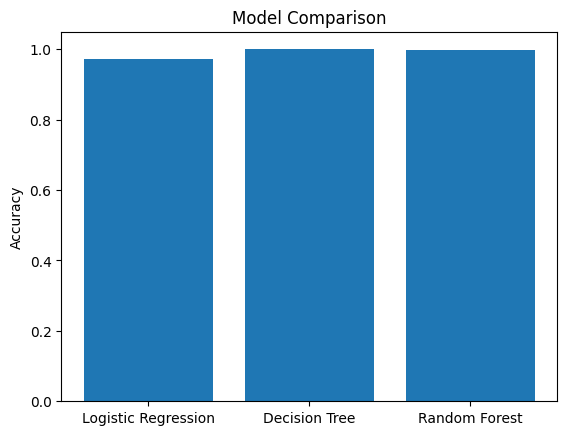

In [11]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [12]:
print("Decision Tree Train Accuracy:", models["Decision Tree"].score(X_train, y_train))
print("Decision Tree Test Accuracy:", models["Decision Tree"].score(X_test, y_test))

print("\nRandom Forest Train Accuracy:", models["Random Forest"].score(X_train, y_train))
print("Random Forest Test Accuracy:", models["Random Forest"].score(X_test, y_test))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.9994

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9986


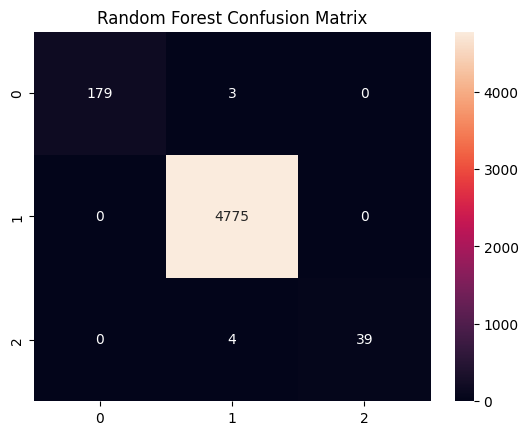

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_preds = models["Random Forest"].predict(X_test)

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()